Author: Daniel Abadjiev  
Date: July 24, 2026  
Description: Notebook to quickly look at timing distributions to make sure they're sensible for signal.  

In [14]:
import numpy as numpy
import tfLoaderUtils
import pandas as pd
import sys
# sys.path.append("../MuC_Smartpix_ML")
# import Model_Classes
import ASICModel
import matplotlib.pyplot as plt

2026-07-24 05:57:05.699997: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-24 05:57:05.730520: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-24 05:57:05.730554: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-24 05:57:05.731507: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-24 05:57:05.736880: I tensorflow/core/platform/cpu_feature_guar

<class 'MuC_Smartpix_ML.Model_Classes.SmartPixModel'>
weird import error
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
True
True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
False


2026-07-24 05:57:07.726669: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-07-24 05:57:07.732158: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [ ]:
tfRecordFolder = tfRecordFolder = "/local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized"
tfRecordFolder = tfRecordFolder = "/local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized"
model = ASICModel.ModelASIC(tfRecordFolder = tfRecordFolder)   #could be any, just this one easiest in this folder

In [19]:
key="adjusted_hit_time_30ps_gaussian"
model.x_feature_description = model.x_feature_description + [key]
model.loadTfRecords()
xTrain, yTrain = tfLoaderUtils.odgToVect(model.training_generator)
xTest, yTest = tfLoaderUtils.odgToVect(model.validation_generator)

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41


In [77]:
pklPath = "./validationPlots/plots/dfOfTruthBib.pkl"
pklPath = "./validationPlots/plots/dfOfTruth.pkl"
# pklPath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/paperPlots/datasetPlots/dfOfTruth.pkl"
pklPath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/validationPlots/savedPklsFromFullDataset/dfOfTruth.pkl"
# pklPath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb/plots/dfOfTruth.pkl"
truthDF = pd.read_pickle(pklPath)

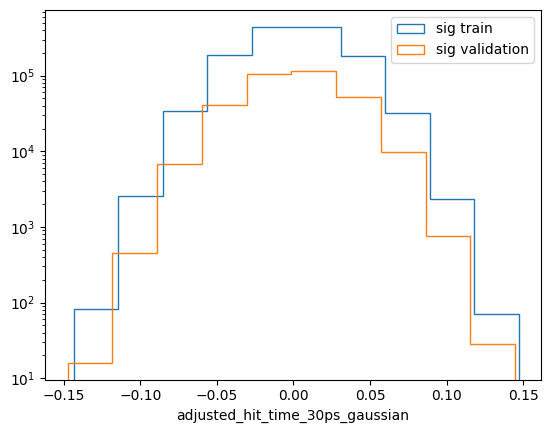

length train sig 1325915
length test sig 330741
length train + test sig 1656656
length parquet sig      1634689


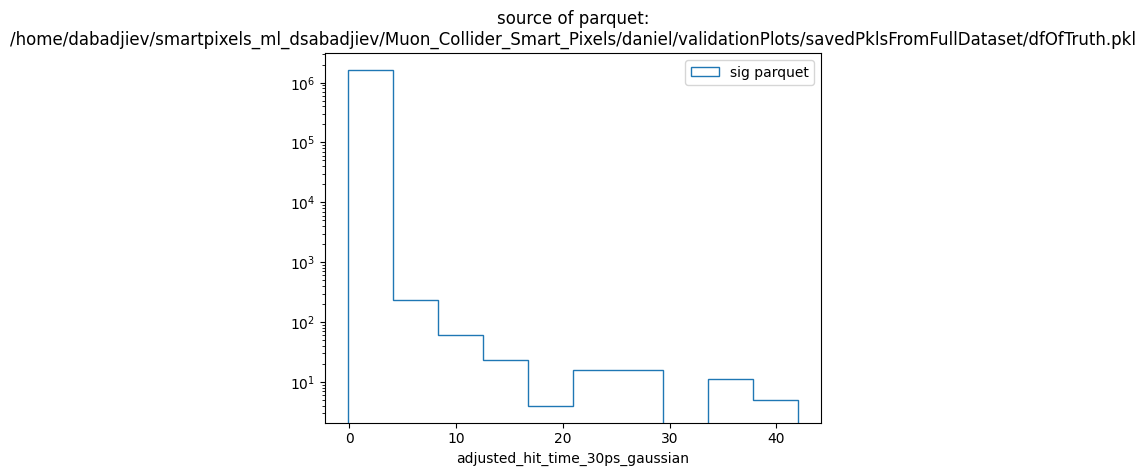

In [78]:
plt.hist(xTrain[key].numpy()[yTrain.numpy().ravel()==1],histtype="step",label="sig train")
# plt.hist(xTrain[key].numpy()[yTrain.numpy().ravel()==0],histtype="step",label="bib train")
plt.hist(xTest[key].numpy()[yTest.numpy().ravel()==1],histtype="step",label="sig validation")
# plt.hist(xTest[key].numpy()[yTest.numpy().ravel()==0],histtype="step",label="bib validation")
plt.yscale("log")
plt.xlabel(key)
plt.legend()
plt.show()

plt.hist(truthDF.query("source == 'sig'")[key],label="sig parquet",histtype='step')
plt.yscale("log")
plt.xlabel(key)
plt.title(f"source of parquet:\n{pklPath}")
plt.legend()

print(f"length train sig {len(xTrain[key].numpy()[yTrain.numpy().ravel()==1])}")
print(f"length test sig {len(xTest[key].numpy()[yTest.numpy().ravel()==1])}")
print(f"length train + test sig {len(xTest[key].numpy()[yTest.numpy().ravel()==1]) + len(xTrain[key].numpy()[yTrain.numpy().ravel()==1])}")
print(f"""length parquet sig      {len(truthDF.query("source == 'sig'"))}""")


length train bib 1325915
length test bib 330741
length train + test bib 1656656
length parquet bib      1656656


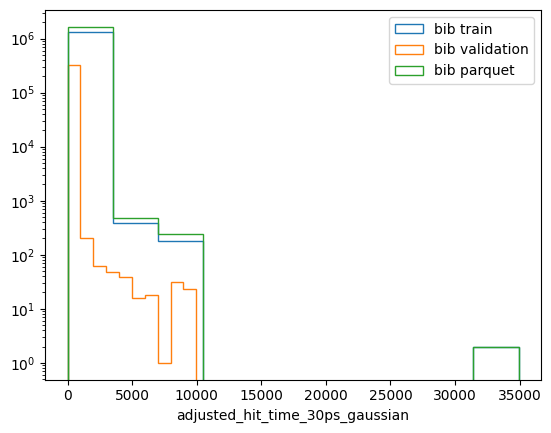

In [59]:
# plt.hist(xTrain[key].numpy()[yTrain.numpy().ravel()==1],histtype="step",label="sig train")
plt.hist(xTrain[key].numpy()[yTrain.numpy().ravel()==0],histtype="step",label="bib train")
# plt.hist(xTest[key].numpy()[yTest.numpy().ravel()==1],histtype="step",label="sig validation")
plt.hist(xTest[key].numpy()[yTest.numpy().ravel()==0],histtype="step",label="bib validation")
plt.yscale("log")
plt.xlabel(key)
plt.legend()
# plt.show()
plt.hist(truthDF.query("source == 'bib_mm' or source == 'bib_mp'")[key],label="bib parquet",histtype='step')
plt.yscale("log")
plt.xlabel(key)
plt.legend()

print(f"length train bib {len(xTrain[key].numpy()[yTrain.numpy().ravel()==0])}")
print(f"length test bib {len(xTest[key].numpy()[yTest.numpy().ravel()==0])}")
print(f"length train + test bib {len(xTest[key].numpy()[yTest.numpy().ravel()==0]) + len(xTrain[key].numpy()[yTrain.numpy().ravel()==0])}")
print(f"""length parquet bib      {len(truthDF.query("source == 'bib_mm' or source == 'bib_mp'"))}""")

In [9]:
from validationPlots.SpixPlotter import SmartpixPlotter
from pathlib import Path

###########################################################################
########## Defaults for data directories, copied from runPlots2.py
repodir = Path(".").resolve().parent
print("Assuming you are starting in .....paperPlots, so git repo dir is ", repodir)
assert repodir.parts[-1] == 'Muon_Collider_Smart_Pixels'
dataDir_all = "Data_Set_2026Feb"
if dataDir_all is not None:
    print("Using a dataset directory with subfolders, following Eliza's 2026 dataset format, ignoring other directories")
    print("Setting plot directory inside dataset folder")
    #either dataDir_all is a string witht the dataset name, in which case join paths from DataFiles and repodir
    #otherwise, dataDir_all should be an absolute path to the dataset
    # if 
    datasetPath = Path(dataDir_all)
    if len(datasetPath.parts) == 1:
        print("looking for the dataset in Data_Files")
        datasetDir = repodir.joinpath("Data_Files").joinpath(datasetPath)
    else:
        print("assuming dataset passed is in an absolute path")
        datasetDir = datasetPath
    parquetDir_all = datasetDir.joinpath("Parquet_Files")
    trackDirBib_mm = datasetDir.joinpath("Track_Lists")
    trackDirBib_mp = datasetDir.joinpath("Track_Lists")
    trackDirSig = datasetDir.joinpath("Track_Lists")
    # PLOT_DIR = datasetDir.joinpath("plots")
###########################################################################

STYLESHEET = "seaborn-v0_8-colorblind"
def main(parquetDir_all = "hahaha",#"/local/d1/smartpixML/bigData/allData/",     #this should be not used?          
            #skip_indices = list(range(1730 - 124+87, 1769)),
            trackDirBib_mm = trackDirBib_mm,
            trackDirBib_mp = trackDirBib_mp,
            trackDirSig = trackDirSig,
            processRecon = False,
            interactivePlots = False,
            PLOT_DIR = "../paperPlots/datasetPlots",
            savedPklFromParquet = True,
            processTracks = True,
            processOldTracks = False,
            plotTracklists = True,
            plotParquets = True,
            styleSheet=STYLESHEET,):
    plotter = SmartpixPlotter(
                    #  parquetDir_mm = parquetDir_mm , #Not yet implemented
                    #  parquetDir_mp = parquetDir_mp ,
                    #  parquetDir_sig = parquetDir_sig ,
                    parquetDir_all = parquetDir_all ,
                    skip_indices = None,#list(range(1730 - 124+87, 1769)),
                    trackDirBib_mm = trackDirBib_mm,
                    trackDirBib_mp = trackDirBib_mp,
                    trackDirSig = trackDirSig,
                    processRecon = processRecon,
                    interactivePlots=interactivePlots,
                    PLOT_DIR = PLOT_DIR,# os.path.join(os.path.dirname(os.path.abspath(__file__)), "plots"),
                    savedPklFromParquet = savedPklFromParquet,
                    processTracks = processTracks,
                    processOldTracks = processOldTracks,
                    plotTracklists = plotTracklists,
                    plotParquets = plotParquets,
                    styleSheet = styleSheet,
                    )
    plotter.runPlots()
    return plotter

Assuming you are starting in .....paperPlots, so git repo dir is  /home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels
Using a dataset directory with subfolders, following Eliza's 2026 dataset format, ignoring other directories
Setting plot directory inside dataset folder
looking for the dataset in Data_Files


In [10]:
plotter = main()

loading data, Currently loading settings: 
processRecon: False
savedPklFromParquet: True
interactivePlots: False
[    488     489     490 ... 3119334 3119335 3119336]
len truthSig: 1600000
len truthBib: 1600000
len truthBib_mm: 809783
len truthBib_mp: 790217
fraction of total that are MM: 0.2530571875
fraction of total that are MP: 0.2469428125
fraction of total that are Bib: 0.5
fraction of total that are Sig: 0.5
Finished loading parquet data [not counting tracks], now proceeding to plotting or tracklists
Start loading track data
/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb/Track_Lists
/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb/Track_Lists
/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb/Track_Lists
Loaded tracks with counting of 
 bib mm: 875437 
 bib mp: 856000  
 bib total: 1731437 
 Signal: 1750000 
Nan m count: 0
Nan m count: 0

/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/validationPlots/plotUtils.py:458: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/validationPlots/plotUtils.py:460: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(os.path.join(PLOT_DIR, plotName), dpi=300, bbox_inches='tight',transparent=transparent)


Plot saved as: ../paperPlots/datasetPlots/signal_bib_cotAvsZ_cotBvsY.png
BIB    max is 7855.694258939272 and min is 0.1369825130818242
Signal max is 946.0718994474978 and min is 0.34588254046467304
So bins go from 0.1369825130818242 to 7855.694258939272, and there are 120 bins with log spacing
BIB    max is 2991.6135026194033 and min is 26.442914726041813
Signal max is 1725.4422535037163 and min is 26.497042619731744
So bins go from 26.442914726041813 to 2991.6135026194033, and there are 120 bins with log spacing
Plot saved as: ../paperPlots/datasetPlots/BetaBloch3.png
Setting the histogram bins to be the collective range for BIB and Signal of betaGamma
BIB    betaGamma max is 7855.694258939272 and min is 0.1369825130818242
Signal betaGamma max is 946.0718994474978 and min is 0.34588254046467304
So bins go from 0.1369825130818242 to 7855.694258939272, and there are 30 bins with linear spacing
Setting the histogram bins to be the collective range for BIB and Signal of pathLength
BIB    

/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/validationPlots/plotUtils.py:1297: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0,1000])
/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/validationPlots/plotUtils.py:1298: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim([0,200])


Plot saved as: ../paperPlots/datasetPlots/BetaBlochCurve.png
length of stuff
120
119
119
119
119
Plot saved as: ../paperPlots/datasetPlots/BetaBlochCurve2.png
Setting the histogram bins to be the collective range for BIB and Signal of p_calc1
BIB    p_calc1 max is 4.014259766317968 and min is 6.999806418481216e-05
Signal p_calc1 max is 99.99979977160052 and min is 0.036559784527115946
So bins go from 6.999806418481216e-05 to 99.99979977160052, and there are 30 bins with linear spacing
Setting the histogram bins to be the collective range for BIB and Signal of p_calc2
BIB    p_calc2 max is 4.014304525409801 and min is 6.0553865732732337e-05
Signal p_calc2 max is 99.99971178487755 and min is 0.036562496913625994
So bins go from 6.0553865732732337e-05 to 99.99971178487755, and there are 30 bins with linear spacing
Setting the histogram bins to be the collective range for BIB and Signal of p_calc3
BIB    p_calc3 max is 4.014304525409801 and min is 6.055386573273234e-05
Signal p_calc3 max i

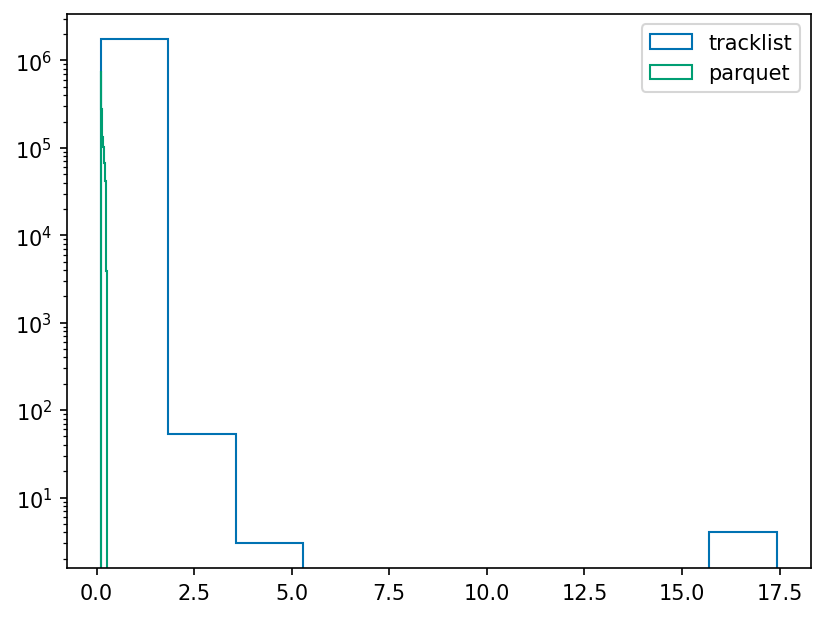

0.25642


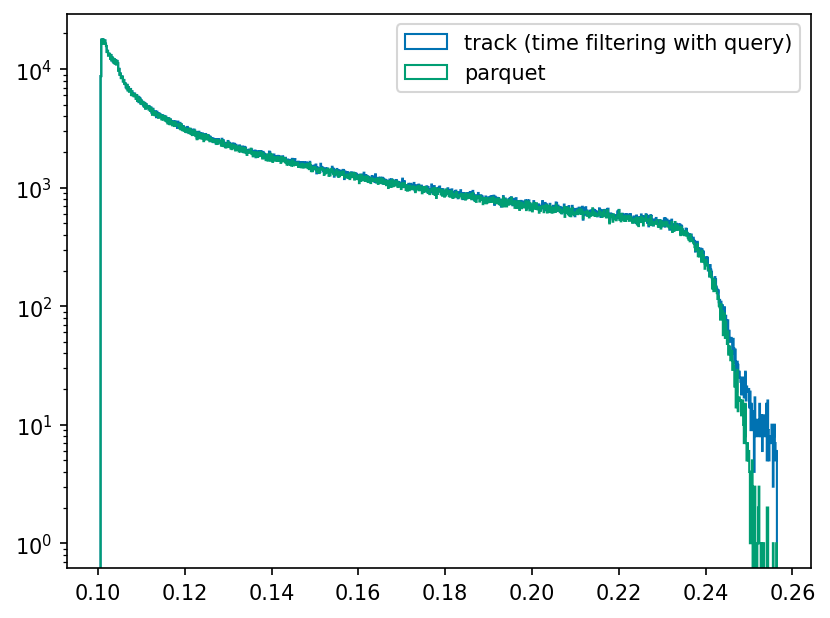

In [84]:
plt.hist(plotter.tracksSig["t"],histtype="step",label='tracklist')
plt.hist(plotter.truthSig["hit_time"],histtype="step",label="parquet")
plt.yscale('log')
plt.legend()
plt.show()
print(np.max(plotter.truthSig["hit_time"]))
hitTimeAdjustment = np.max(plotter.truthSig["hit_time"])
# hitTimeAdjustment = 0.26
bigTimeSig = plotter.tracksSig.query("t>@hitTimeAdjustment")
smallTimeSig = plotter.tracksSig.query("t<@hitTimeAdjustment")
plt.hist(smallTimeSig["t"],histtype="step",label="track (time filtering with query)",bins=1000)
plt.hist(plotter.truthSig["hit_time"],histtype="step",label='parquet',bins=1000)
plt.legend()
plt.yscale('log')
# plotter.truthDF

0.02965
0.02965


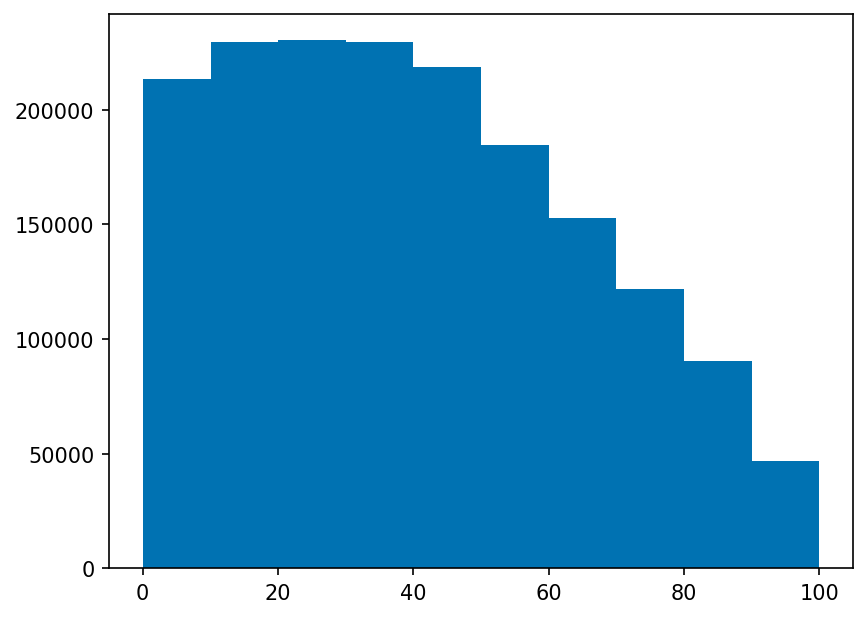

In [85]:
import numpy as np
plt.hist(plotter.truthSig["pt"])
print(np.min(plotter.truthSig["pt"]))
print(np.min(plotter.truthSig["pt"]))

        cota     cotb        p  flp  ...       n_z         x         y         z
53   0.19943 -0.48666  0.00028    1  ...  0.000327  0.176507 -0.430721  0.885056
273  1.89231 -1.62012  0.00081    1  ...  0.000398  0.704947 -0.603547  0.372532
274 -0.60674 -0.40299  0.00060    1  ...  0.000640 -0.490435 -0.325741  0.808311
275  0.98633  0.22401  0.00059    1  ...  0.000548  0.693460  0.157495  0.703071
276 -0.36620 -0.24919  0.00027    1  ...  0.000326 -0.334824 -0.227840  0.914320

[5 rows x 17 columns]
Index(['cota', 'cotb', 'p', 'flp', 'ylocal', 'zglobal', 'pt', 't', 'hit_pdg',
       'm', 'scalePion', 'n_x', 'n_y', 'n_z', 'x', 'y', 'z'],
      dtype='object')


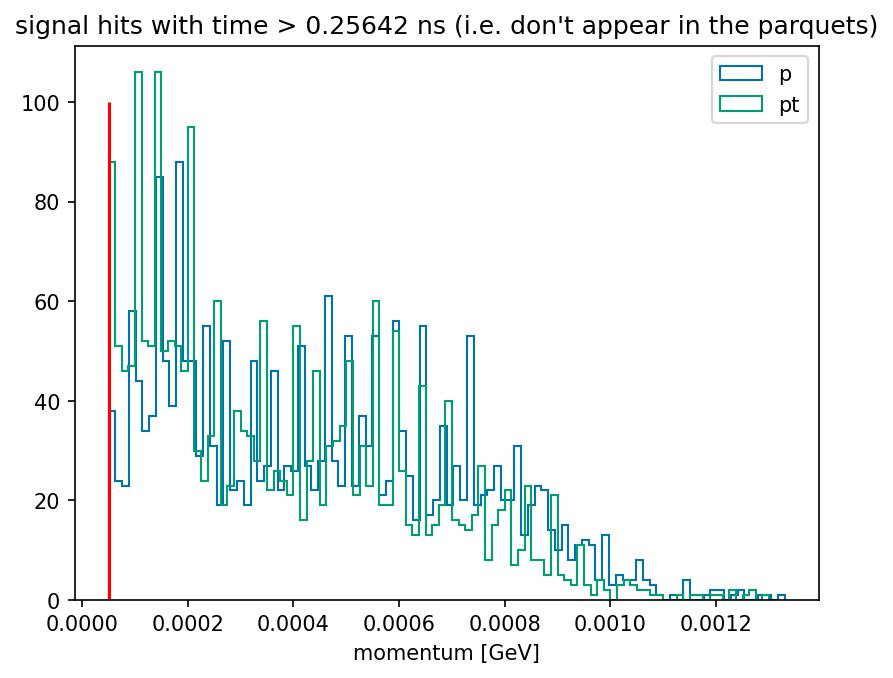

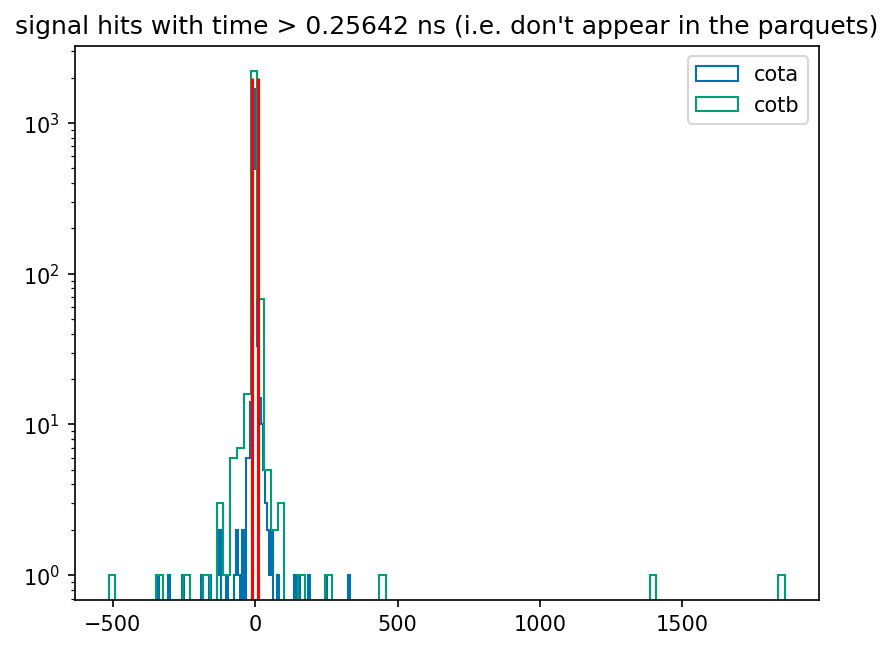

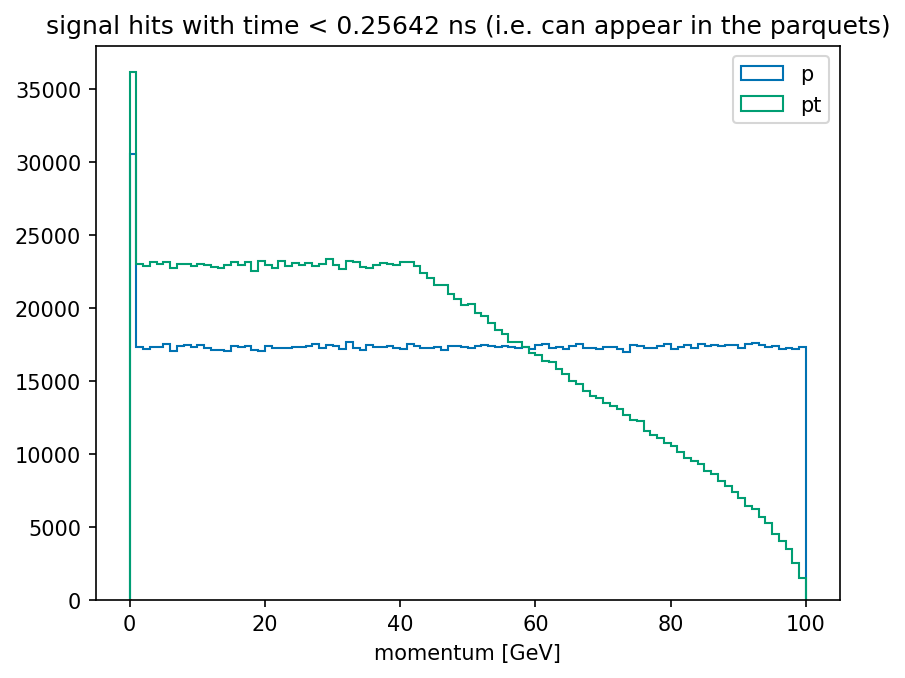

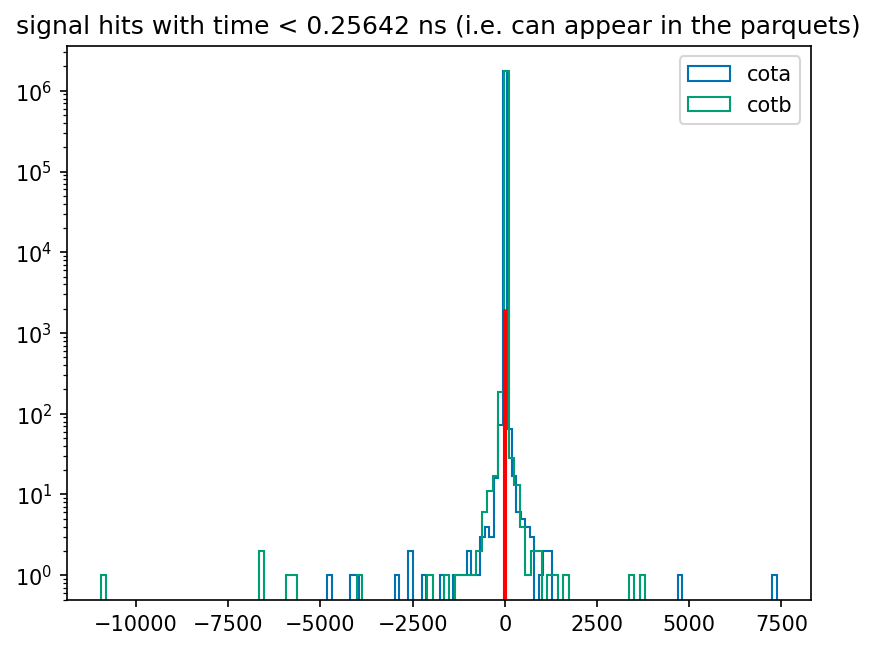

In [104]:
print(bigTimeSig.head())
print(bigTimeSig.keys())
plt.hist(bigTimeSig["p"],label="p",histtype="step",bins=100)
plt.hist(bigTimeSig["pt"],label="pt",histtype="step",bins=100)
plt.title(f"signal hits with time > {hitTimeAdjustment} ns (i.e. don't appear in the parquets)")
plt.legend()
plt.xlabel("momentum [GeV]")
plt.vlines(0.00005,0,100,color="red")
plt.show()

plt.hist(bigTimeSig["cota"],label="cota",histtype="step",bins=100)
plt.hist(bigTimeSig["cotb"],label="cotb",histtype="step",bins=100)
plt.title(f"signal hits with time > {hitTimeAdjustment} ns (i.e. don't appear in the parquets)")
plt.legend()
plt.yscale("log")
plt.vlines([10,-10],0,2000,color="red")
plt.show()


plt.hist(smallTimeSig["p"],label="p",histtype="step",bins=100)
plt.hist(smallTimeSig["pt"],label="pt",histtype="step",bins=100)
plt.title(f"signal hits with time < {hitTimeAdjustment} ns (i.e. can appear in the parquets)")
plt.legend()
plt.xlabel("momentum [GeV]")
plt.vlines(0.00005,0,100,color="red")
plt.show()

plt.hist(smallTimeSig["cota"],label="cota",histtype="step",bins=100)
plt.hist(smallTimeSig["cotb"],label="cotb",histtype="step",bins=100)
plt.title(f"signal hits with time < {hitTimeAdjustment} ns (i.e. can appear in the parquets)")
plt.legend()
plt.yscale("log")
plt.vlines([10,-10],0,2000,color="red")
plt.show()

Index(['cota', 'cotb', 'p', 'flp', 'ylocal', 'zglobal', 'pt', 't', 'hit_pdg',
       'm', 'scalePion', 'n_x', 'n_y', 'n_z', 'x', 'y', 'z'],
      dtype='object')
[13]


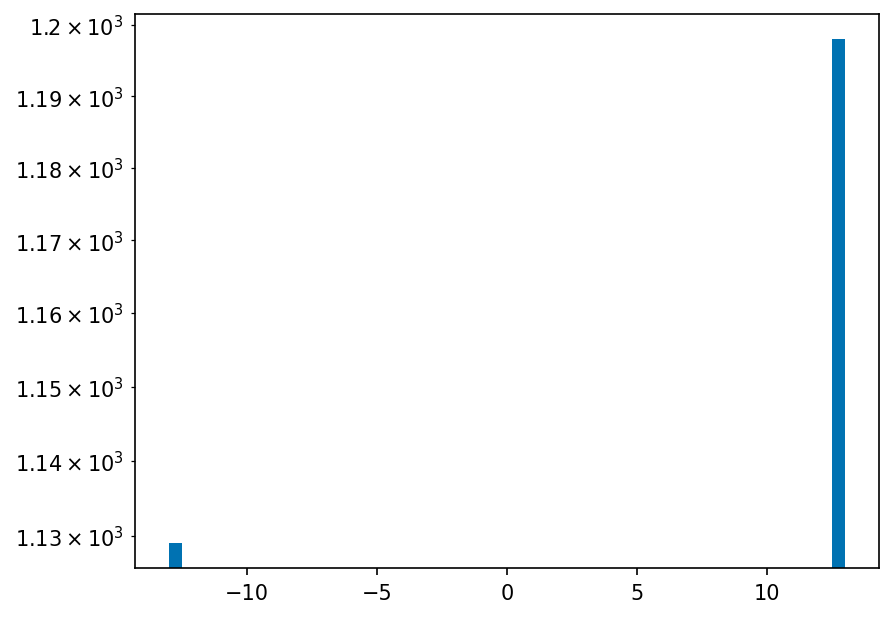

In [112]:
print(bigTimeSig.keys())
plt.hist(bigTimeSig["hit_pdg"],bins=50)
plt.yscale('log')
print(np.unique(np.abs(bigTimeSig["hit_pdg"])))

In [89]:
print(len(bigTimeSig))
print(len(bigTimeSig.query("cota > -10")))
print(len(bigTimeSig.query("cota > -10 and cota < 10")))
print(len(bigTimeSig.query("cota > -10 and cota < 10 and cotb < 10")))
print(len(bigTimeSig.query("cota > -10 and cota < 10 and cotb < 10 and cotb > -10")))
print(len(bigTimeSig.query("cota > -10 and cota < 10 and cotb < 10 and cotb > -10 and p > 0.00005")))
print(len(bigTimeSig.query("cota > -10 and cota < 10 and cotb < 10 and cotb > -10 and p > 0.00005 and pt > 0.00005")))

2327
2275
2218
2187
2158
2156
2126


In [51]:
# for key in bigTimeSig.keys():
#     plt.hist(bigTimeSig[key])
#     plt.xlabel(key)
#     plt.yscale('log')
#     plt.show()

In [99]:
df = pd.DataFrame()
# print(plotter.tracksSig.keys())
adjustedHitTimeTracklist =  plotter.tracksSig["t"]-1e6*np.sqrt(plotter.tracksSig['zglobal']**2+30**2)/299792458

(0.0, 1.0)

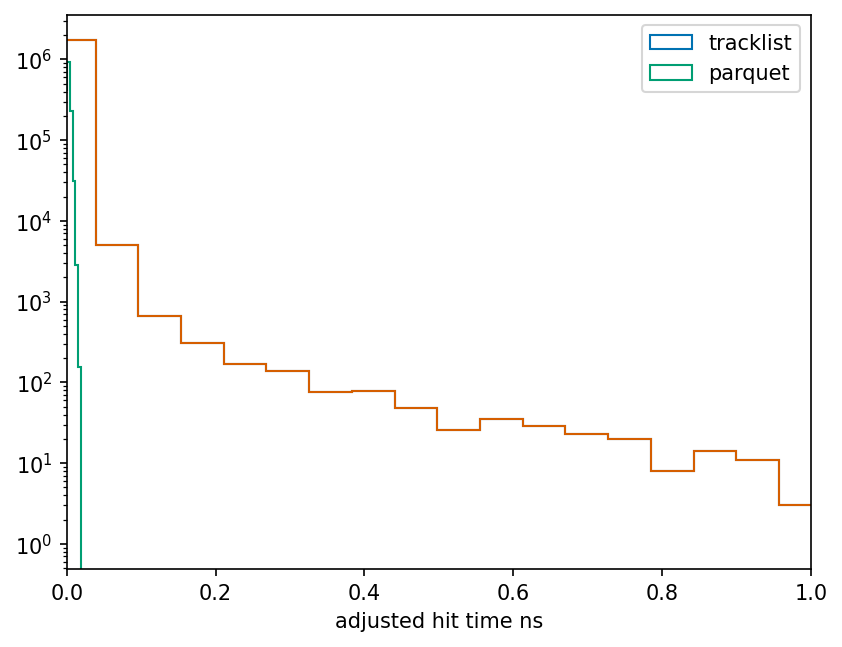

In [122]:
plt.hist(adjustedHitTimeTracklist,bins=300,label="tracklist",histtype="step")
# plt.hist(plotter.truthSig["adjusted_hit_time"],histtype="step",label="parquet",histtype="step")
plt.hist(plotter.truthSig["adjusted_hit_time"],label="parquet",histtype="step")
plt.legend()
plt.yscale('log')
plt.xlabel("adjusted hit time ns")
plt.hist(adjustedHitTimeTracklist,bins=300,label="tracklist",histtype="step")
# plt.hist(plotter.truthSig["adjusted_hit_time"],histtype="step",label="parquet",histtype="step")
# plt.hist(plotter.truthSig["adjusted_hit_time"],label="parquet",histtype="step")
# plt.legend()
# plt.yscale('log')
# plt.xlabel("adjusted hit time ns")
plt.xlim([0,1])

In [133]:
file = "./tracks.txt"
trackHeader = ["zglobal","t","adjusted_hit_time","p","pt"]
quickTracks = pd.read_csv(file, sep=' ', header=None, names=trackHeader)

Text(0.5, 1.0, "quick regeneration of a couple of track hits taken from the slcio, with p and pt filtering\nNotice how it goes past 0.26 ns? That's not like the parquets aaaaaaaa")

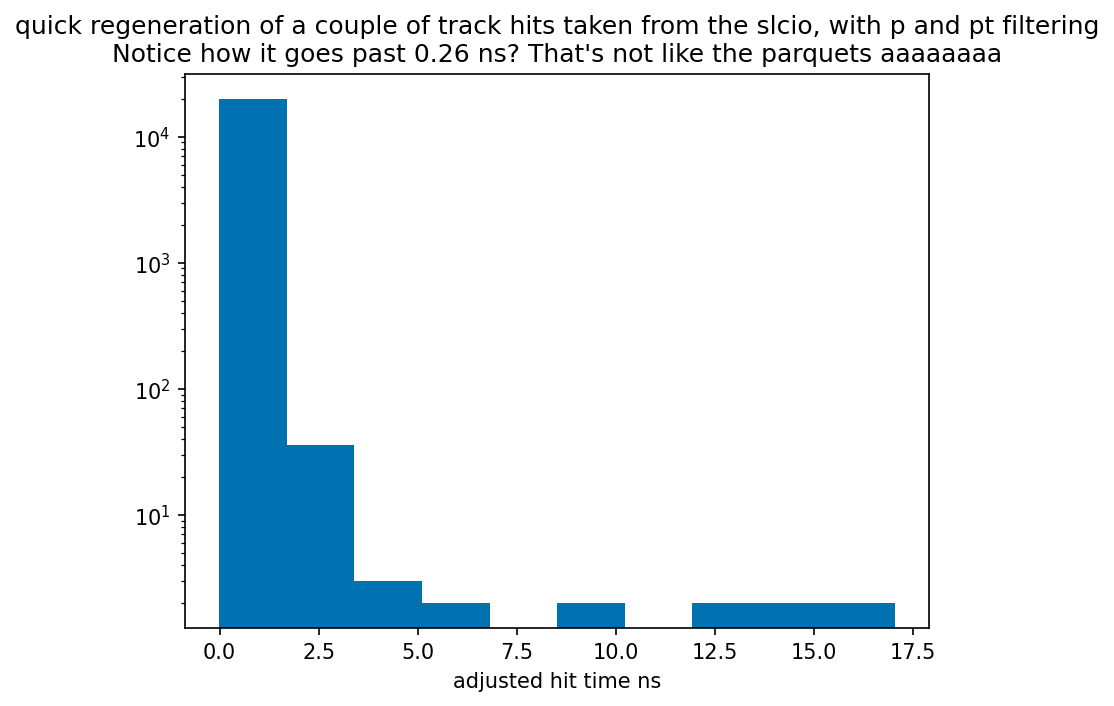

In [134]:
plt.hist(quickTracks["adjusted_hit_time"])
plt.yscale("log")
plt.xlabel("adjusted hit time ns")
plt.title("quick regeneration of a couple of track hits taken from the slcio, with p and pt filtering\nNotice how it goes past 0.26 ns? That's not like the parquets aaaaaaaa")